# ***Implementing ResNet Models***

***ResNet architecture for different layered models***

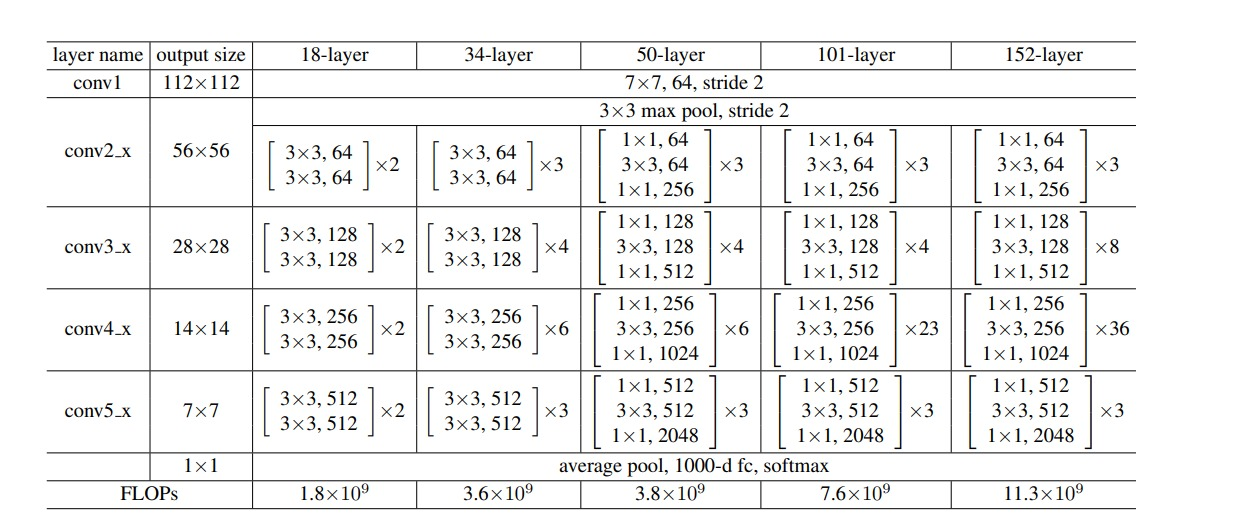

***Defining ResNet Models from scratch [PyTorch]***

In [ ]:
import torch
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(BasicBlock, self).__init__()
        self.expansion = 4

        # first in-layer of the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # second in-layer of the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # third in-layer of the block
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample

    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)
        return x


class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        super(ResNet, self).__init__()

        # conv1 layer
        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()

        # conv2 layer: maxpool part
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Main ResNet layers
        self.layer1 = self._make_layer(block, layers[0], out_channels=64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], out_channels=256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], out_channels=512, stride=2)

        # Final layer
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512 * 4, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * 4:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * 4, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels * 4)
            )

        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * 4

        for i in range(num_residual_blocks - 1):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


# ResNet variants
def ResNet50(img_channels=3, num_classes=1000):
    return ResNet(BasicBlock, [3, 4, 6, 3], img_channels, num_classes)

def ResNet101(img_channels=3, num_classes=1000):
    return ResNet(BasicBlock, [3, 4, 23, 3], img_channels, num_classes)

def ResNet152(img_channels=3, num_classes=1000):
    return ResNet(BasicBlock, [3, 8, 36, 3], img_channels, num_classes)




***Loading the data, training and evaluating it***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Transform: Resize to 224x224 and convert grayscale to 3-channel
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # ResNet expects 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load data-set
train_data = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.4MB/s]


In [ ]:
# 3. Intializing model, loss, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet50().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 4. Training loop
epochs = 10
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], [] # Added lists for loss

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    running_loss = 0.0 # Added variable for running training loss
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0) # Accumulate loss
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / total # Calculate average training loss
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss) # Append training loss

    # Validation accuracy and loss
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0 # Added variable for running validation loss
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels) # Calculate validation loss
            running_loss += loss.item() * images.size(0) # Accumulate loss
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = running_loss / total # Calculate average validation loss
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss) # Append validation loss

    print(f"Epoch {epoch+1}/{epochs}: Train Acc = {train_acc:.4f}, Train Loss = {train_loss:.4f}, Val Acc = {val_acc:.4f}, Val Loss = {val_loss:.4f}") # Modified print statement

Epoch 1/10: Train Acc = 0.8096, Train Loss = 0.5337, Val Acc = 0.8523, Val Loss = 0.4122
Epoch 2/10: Train Acc = 0.8840, Train Loss = 0.3204, Val Acc = 0.8781, Val Loss = 0.3538
Epoch 3/10: Train Acc = 0.9010, Train Loss = 0.2700, Val Acc = 0.8236, Val Loss = 0.4947
Epoch 4/10: Train Acc = 0.9122, Train Loss = 0.2410, Val Acc = 0.8788, Val Loss = 0.3639
Epoch 5/10: Train Acc = 0.9194, Train Loss = 0.2234, Val Acc = 0.6653, Val Loss = 1.0642
Epoch 6/10: Train Acc = 0.9262, Train Loss = 0.2039, Val Acc = 0.9138, Val Loss = 0.2360
Epoch 7/10: Train Acc = 0.9313, Train Loss = 0.1884, Val Acc = 0.9160, Val Loss = 0.2461
Epoch 8/10: Train Acc = 0.9363, Train Loss = 0.1737, Val Acc = 0.9173, Val Loss = 0.2311
Epoch 9/10: Train Acc = 0.9424, Train Loss = 0.1594, Val Acc = 0.9212, Val Loss = 0.2297
Epoch 10/10: Train Acc = 0.9481, Train Loss = 0.1432, Val Acc = 0.9155, Val Loss = 0.2704


In [ ]:
# @title
# 4. Training loop
epochs = 10
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
  model.train()
  correct, total = 0, 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    _,preds = torch.max(outputs, 1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

  train_acc = correct / total
  train_acc_list.append(train_acc)

  # Validation accuracy
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, preds = torch.max(outputs, 1)
      correct += (preds == labels).sum().item() # Corrected typo here
      total += labels.size(0)

  val_acc = correct / total
  val_acc_list.append(val_acc)

  print(f"Epoch {epoch+1}/{epochs}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

  # Save checkpoint
  checkpoint = {
      'epoch': epoch + 1,
      'state_dict': model.state_dict(),
      'optimizer': optimizer.state_dict()
  }
  torch.save(checkpoint, f'resnet50_checkpoint_epoch_{epoch+1}.pth')

***Accuracy Results***

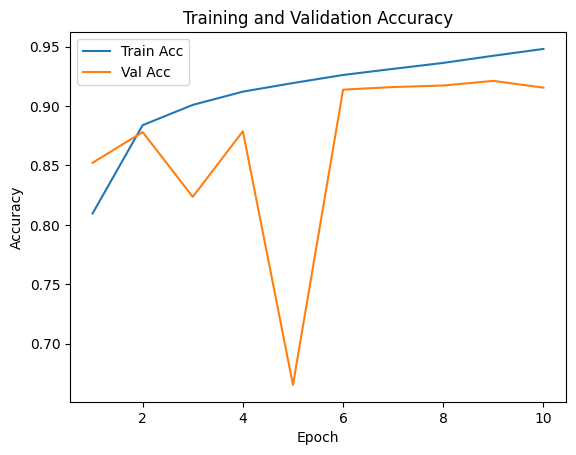

In [ ]:
# 5. Plotting accuracy
import numpy as np
import matplotlib.pyplot as plt

plt.plot(range(1, epochs+1), train_acc_list, label="Train Acc")
plt.plot(range(1, epochs+1), val_acc_list, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()